### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


### Load the CSV

In [2]:
df = pd.read_csv("human_eval_responses.csv")

print(f"✅ Loaded {len(df)} evaluator responses")
print(f"\nColumns found:\n")
for col in df.columns:
    print(f"  - {col}")


✅ Loaded 5 evaluator responses

Columns found:

  - Timestamp
  - Please rate each translation on three criteria using a 1–5 scale:
  - What is your primary language?
  - Q2.  How would you rate your Sesotho proficiency?
  - Q3.  What is your professional background? (Select all that apply)
  - Adequacy
  - Fluency
  - Adequacy.1
  - Fluency.1
  - Medical Accuracy
  - Adequacy.2
  - Fluency.2
  - Medical Accuracy.1
  -  Adequacy
  - Fluency.3
  -  Medical Accuracy
  - Adequacy.3
  - Fluency.4
  - Medical Accuracy.2
  - Adequacy.4
  - Fluency.5
  - Medical Accuracy.3
  -  Adequacy.1
  - Fluency.6
  - Medical Accuracy.4
  - Adequacy.5
  - Fluency.7
  - Medical Accuracy.5
  - Adequacy.6
  - Fluency.8
  -  Medical Accuracy.1
  -  Adequacy.2
  - Fluency.9
  - Medical Accuracy.6


### Rename Columns

In [ ]:
# rename by column position instead of by name.

criteria = {"Adequacy", "Fluency", "Medical Accuracy"}


def normalize_score_column_name(col: str) -> str:
    base = col.strip()
    if "." in base:
        base = base.split(".", 1)[0].strip()
    return base


score_cols = [col for col in df.columns if normalize_score_column_name(col) in criteria]

print(f"Found {len(score_cols)} score columns (expected 30):\n")
for i, col in enumerate(score_cols):
    print(f"  [{i}] {col}")


Found 5 score columns (expected 30):

  [0] Adequacy
  [1] Fluency
  [2] Medical Accuracy
  [3]  Adequacy
  [4]  Medical Accuracy


In [4]:
# Build the rename map from the 30 score columns in order
criteria_cycle = ["adequacy", "fluency", "medical_accuracy"]
new_names = {}

for i, col in enumerate(score_cols):
    sentence_num  = (i // 3) + 1          # 1–10
    criterion     = criteria_cycle[i % 3] # cycles: adequacy → fluency → medical_accuracy
    new_names[col] = f"s{sentence_num}_{criterion}"

df = df.rename(columns=new_names)

print("✅ Renamed successfully. Sample check:")
print([c for c in df.columns if c.startswith("s")])


✅ Renamed successfully. Sample check:
['s1_adequacy', 's1_fluency', 's1_medical_accuracy', 's2_adequacy', 's2_fluency']


### Group Scores by Criterion

In [9]:
adequacy_cols  = [f"s{i}_adequacy"         for i in range(1, 11)]
fluency_cols   = [f"s{i}_fluency"          for i in range(1, 11)]
accuracy_cols  = [f"s{i}_medical_accuracy" for i in range(1, 11)]
adequacy_cols = [c for c in adequacy_cols if c in df.columns]
fluency_cols = [c for c in fluency_cols if c in df.columns]
accuracy_cols = [c for c in accuracy_cols if c in df.columns]

adequacy_scores = df[adequacy_cols].values.flatten()
fluency_scores   = df[fluency_cols].values.flatten()
accuracy_scores  = df[accuracy_cols].values.flatten()

# Remove any NaN values
adequacy_scores  = adequacy_scores[~np.isnan(adequacy_scores.astype(float))]
fluency_scores   = fluency_scores[~np.isnan(fluency_scores.astype(float))]
accuracy_scores  = accuracy_scores[~np.isnan(accuracy_scores.astype(float))]

print(f"✅ Scores grouped")
print(f"   Adequacy ratings collected  : {len(adequacy_scores)}")
print(f"   Fluency ratings collected   : {len(fluency_scores)}")
print(f"   Accuracy ratings collected  : {len(accuracy_scores)}")


✅ Scores grouped
   Adequacy ratings collected  : 10
   Fluency ratings collected   : 10
   Accuracy ratings collected  : 5


### Print Summary Statistics

In [ ]:
criteria = {
    "Adequacy":         adequacy_scores,
    "Fluency":          fluency_scores,
    "Medical Accuracy": accuracy_scores,
}

available_sentence_count = len(
    {
        int(col_name[1:].split("_", 1)[0])
        for col_name in df.columns
        if col_name.startswith("s") and "_" in col_name and col_name[1:].split("_", 1)[0].isdigit()
    }
)
ratings_per_evaluator = len(adequacy_scores) + len(fluency_scores) + len(accuracy_scores)

print("=" * 55)
print("   HUMAN EVALUATION — SUMMARY STATISTICS")
print("=" * 55)
print(f"  {'Criterion':<20} {'Mean':>6} {'SD':>6} {'Min':>5} {'Max':>5}")
print("-" * 55)

for name, scores in criteria.items():
    scores = scores.astype(float)
    print(f"  {name:<20} {np.mean(scores):>6.2f} "
          f"{np.std(scores):>6.2f} "
          f"{np.min(scores):>5.0f} "
          f"{np.max(scores):>5.0f}")

print("=" * 55)
print(f"\n  Evaluators      : {len(df)}")
print(f"  Sentences       : {available_sentence_count}")
print(f"  Total ratings   : {len(df) * ratings_per_evaluator}")


   HUMAN EVALUATION — SUMMARY STATISTICS
  Criterion              Mean     SD   Min   Max
-------------------------------------------------------
  Adequacy               4.90   0.30     4     5
  Fluency                4.90   0.30     4     5
  Medical Accuracy       1.00   0.00     1     1

  Evaluators      : 5
  Sentences       : 10
  Total ratings   : 150


### Per-Sentence Breakdown Table

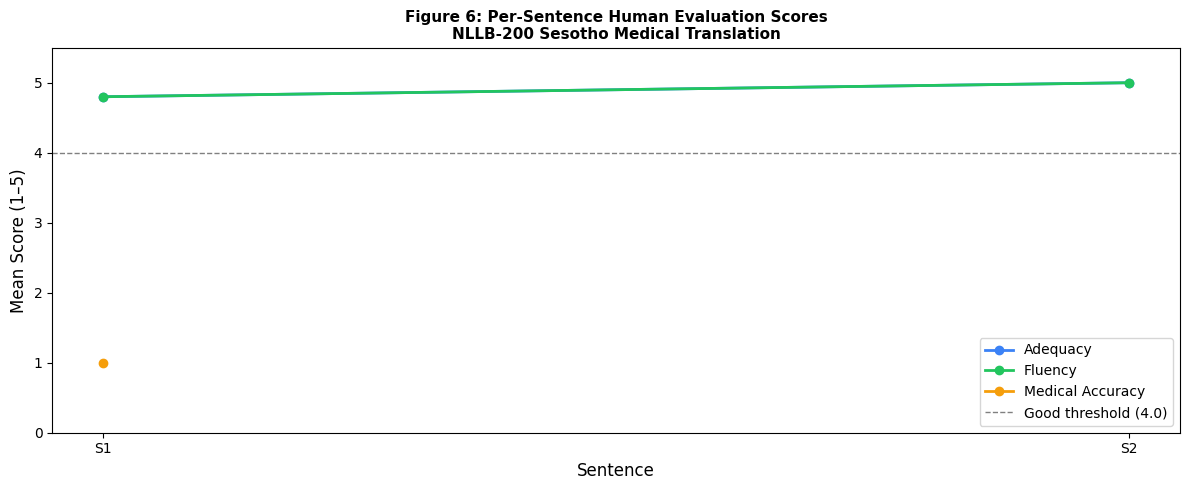

✅ Saved → figure6_per_sentence_scores.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

colors_line = {"Adequacy": "#3b82f6", "Fluency": "#22c55e", "Medical Accuracy": "#f59e0b"}
col_keys = {"Adequacy": "adequacy", "Fluency": "fluency", "Medical Accuracy": "medical_accuracy"}


def available_sentence_numbers(key):
    numbers = []
    for col_name in df.columns:
        if col_name.startswith("s") and col_name.endswith(f"_{key}"):
            sentence_part = col_name[1:].split("_", 1)[0]
            if sentence_part.isdigit():
                numbers.append(int(sentence_part))
    return sorted(set(numbers))


sentence_numbers_all = sorted(
    {
        int(col_name[1:].split("_", 1)[0])
        for col_name in df.columns
        if col_name.startswith("s") and "_" in col_name and col_name[1:].split("_", 1)[0].isdigit()
    }
)

for label, key in col_keys.items():
    sentence_numbers = available_sentence_numbers(key)
    if not sentence_numbers:
        continue

    means_per_sentence = [df[f"s{i}_{key}"].astype(float).mean() for i in sentence_numbers]
    ax.plot(
        sentence_numbers,
        means_per_sentence,
        marker="o",
        linewidth=2,
        label=label,
        color=colors_line[label],
    )

ax.set_xticks(sentence_numbers_all)
ax.set_xticklabels([f"S{i}" for i in sentence_numbers_all])
ax.set_ylim(0, 5.5)
ax.axhline(y=4.0, color="gray", linestyle="--", linewidth=1, label="Good threshold (4.0)")
ax.set_ylabel("Mean Score (1–5)", fontsize=12)
ax.set_xlabel("Sentence", fontsize=12)
ax.set_title(
    "Figure 6: Per-Sentence Human Evaluation Scores\n"
    "NLLB-200 Sesotho Medical Translation",
    fontweight="bold", fontsize=11
)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("figure6_per_sentence_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → figure6_per_sentence_scores.png")


### Bar Chart (Figure 5)

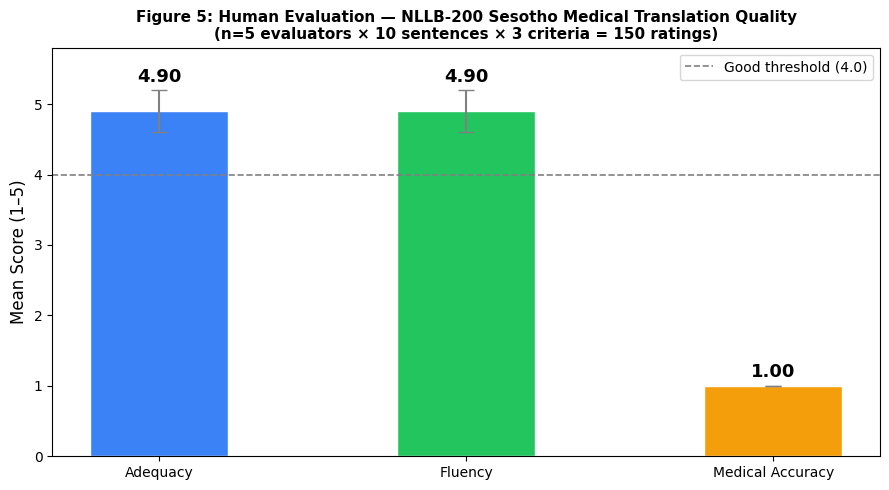

✅ Saved → figure5_human_evaluation.png


In [20]:
names  = list(criteria.keys())
means  = [np.mean(s.astype(float)) for s in criteria.values()]
stds   = [np.std(s.astype(float))  for s in criteria.values()]
colors = ["#3b82f6", "#22c55e", "#f59e0b"]

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    names, means,
    color=colors,
    edgecolor="white",
    width=0.45,
    yerr=stds,
    capsize=6,
    error_kw={"elinewidth": 1.5, "ecolor": "gray"}
)

ax.set_ylim(0, 5.8)
ax.axhline(y=4.0, color="gray", linestyle="--", linewidth=1.2, label="Good threshold (4.0)")
ax.set_ylabel("Mean Score (1–5)", fontsize=12)
ax.set_title(
    "Figure 5: Human Evaluation — NLLB-200 Sesotho Medical Translation Quality\n"
    f"(n={len(df)} evaluators × 10 sentences × 3 criteria = {len(df)*30} ratings)",
    fontweight="bold", fontsize=11
)
ax.legend(fontsize=10)

# Add mean labels above each bar
for bar, mean, std in zip(bars, means, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std + 0.12,
        f"{mean:.2f}",
        ha="center", fontweight="bold", fontsize=13
    )

plt.tight_layout()
plt.savefig("figure5_human_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → figure5_human_evaluation.png")


### Per-Sentence Line Chart (Figure 6)

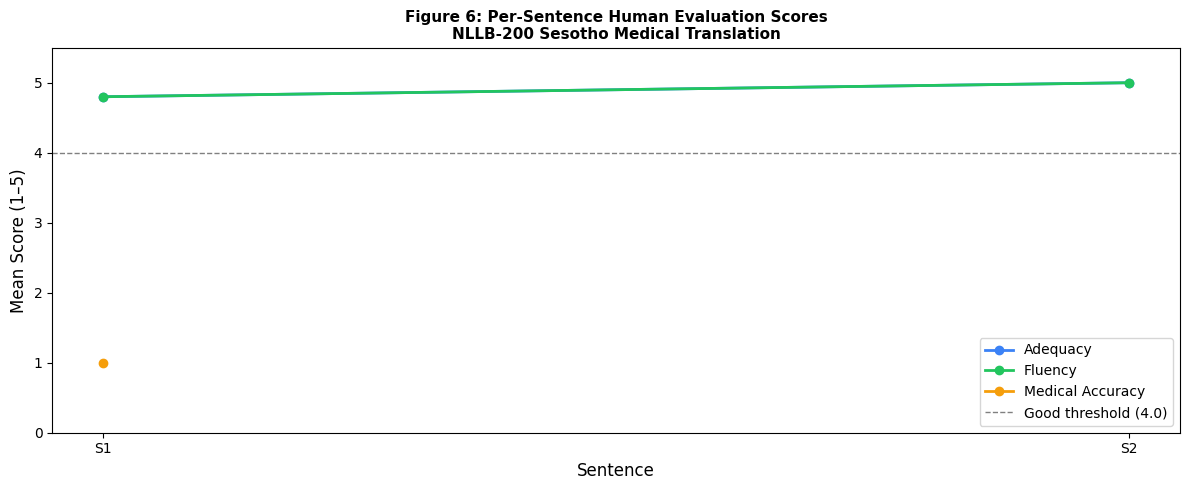

✅ Saved → figure6_per_sentence_scores.png


In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

colors_line = {"Adequacy": "#3b82f6", "Fluency": "#22c55e", "Medical Accuracy": "#f59e0b"}
col_keys = {"Adequacy": "adequacy", "Fluency": "fluency", "Medical Accuracy": "medical_accuracy"}


def available_sentence_numbers(key):
    numbers = []
    for col_name in df.columns:
        if col_name.startswith("s") and col_name.endswith(f"_{key}"):
            sentence_part = col_name[1:].split("_", 1)[0]
            if sentence_part.isdigit():
                numbers.append(int(sentence_part))
    return sorted(set(numbers))


sentence_numbers_all = sorted(
    {
        int(col_name[1:].split("_", 1)[0])
        for col_name in df.columns
        if col_name.startswith("s") and "_" in col_name and col_name[1:].split("_", 1)[0].isdigit()
    }
)

for label, key in col_keys.items():
    sentence_numbers = available_sentence_numbers(key)
    if not sentence_numbers:
        continue

    means_per_sentence = [df[f"s{i}_{key}"].astype(float).mean() for i in sentence_numbers]
    ax.plot(
        sentence_numbers,
        means_per_sentence,
        marker="o",
        linewidth=2,
        label=label,
        color=colors_line[label],
    )

ax.set_xticks(sentence_numbers_all)
ax.set_xticklabels([f"S{i}" for i in sentence_numbers_all])
ax.set_ylim(0, 5.5)
ax.axhline(y=4.0, color="gray", linestyle="--", linewidth=1, label="Good threshold (4.0)")
ax.set_ylabel("Mean Score (1–5)", fontsize=12)
ax.set_xlabel("Sentence", fontsize=12)
ax.set_title(
    "Figure 6: Per-Sentence Human Evaluation Scores\n"
    "NLLB-200 Sesotho Medical Translation",
    fontweight="bold", fontsize=11
)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("figure6_per_sentence_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → figure6_per_sentence_scores.png")


### Export Summary to CSV

In [22]:
summary = pd.DataFrame({
    "Criterion": names,
    "Mean":      [round(np.mean(s.astype(float)), 4) for s in criteria.values()],
    "Std Dev":   [round(np.std(s.astype(float)),  4) for s in criteria.values()],
    "Min":       [int(np.min(s.astype(float)))        for s in criteria.values()],
    "Max":       [int(np.max(s.astype(float)))        for s in criteria.values()],
    "N Ratings": [len(s)                              for s in criteria.values()],
})

summary.to_csv("human_eval_summary.csv", index=False)
print("✅ Saved → human_eval_summary.csv")
print()
print(summary.to_string(index=False))


✅ Saved → human_eval_summary.csv

       Criterion  Mean  Std Dev  Min  Max  N Ratings
        Adequacy   4.9      0.3    4    5         10
         Fluency   4.9      0.3    4    5         10
Medical Accuracy   1.0      0.0    1    1          5
